# UNet EO Training and Segmentation

A lean, top-to-bottom workflow for single-timestep TFRecord loading,
CNN UNet model construction, optional checkpoint loading, fine-tuning,
evaluation, and prediction visualization.

This notebook uses only the target/latest timestep from each temporal
sample. The input tensor passed to the model is shaped `(C, H, W)`, not
`(C, T, H, W)`.

Update the paths and training options in the configuration cell before
running the notebook.


## Environment

This notebook uses the same NumPy-1-compatible data stack as the clean
Prithvi notebook, but it does not need TerraTorch or TorchGeo because the
model is a plain PyTorch CNN.

Run the next cell once when setting up the kernel. Restart the kernel after
installation, then continue from the imports cell. The imports cell also
selects Rasterio's bundled PROJ database to avoid mixed Conda/pip PROJ data.


In [ ]:
%pip install "numpy<2" "opencv-python==4.11.0.86" "opencv-python-headless==4.11.0.86" "albumentations==1.4.6" "rasterio==1.4.4"


In [1]:
import importlib.util
import os
import random
import struct
from pathlib import Path

# Rasterio's wheel contains the PROJ database that matches its PROJ runtime.
_rasterio_spec = importlib.util.find_spec("rasterio")
if _rasterio_spec is not None:
    _proj_data = Path(_rasterio_spec.origin).parent / "proj_data"
    if _proj_data.exists():
        os.environ["PROJ_DATA"] = str(_proj_data)
        os.environ["PROJ_LIB"] = str(_proj_data)

import albumentations as A
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

# Use TensorFlow only for TFRecord parsing; keep GPU memory for PyTorch.
try:
    tf.config.set_visible_devices([], "GPU")
    print("TensorFlow GPU disabled.")
except RuntimeError as error:
    print(
        "TensorFlow GPU was already initialized. "
        "Restart the kernel and run this cell before any TensorFlow work."
    )
    print(error)


# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True


# Data and checkpoint paths
TRAIN_TFRECORD = Path(
    r"D:\Data\ssm_temporal\ssm_footprint_train_new.tfrecord"
)
VAL_TFRECORD = Path(
    r"D:\Data\ssm_temporal\ssm_footprint_no_cloud_val.tfrecord"
)  # Replace with a held-out validation file when available.
FINETUNED_MODEL_PATH = Path("unet_state_dict.pt")
OUTPUT_MODEL_PATH = Path("unet_state_dict_clean.pt")


# Data and model settings
TIMESTEPS = 1
IMAGE_SIZE = 224
IN_CHANNELS = 6
NUM_CLASSES = 3
BASE_CHANNELS = 64
TRAIN_BATCH_SIZE = 8
VAL_BATCH_SIZE = 8
NUM_WORKERS = 0


# Training settings
NUM_EPOCHS = 50
LEARNING_RATE = 1e-3
RUN_TRAINING = True



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("PROJ data:", os.environ.get("PROJ_DATA"))
for label, path in {
    "train data": TRAIN_TFRECORD,
    "validation data": VAL_TFRECORD,
    "fine-tuned model": FINETUNED_MODEL_PATH,
}.items():
    print(f"{label:20s}: {path} ({'found' if path.exists() else 'missing'})")

if TRAIN_TFRECORD == VAL_TFRECORD:
    print("Warning: training and validation currently use the same TFRecord.")


c:\Users\emmanuelasare\AppData\Local\anaconda3\envs\ml-env2\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TensorFlow GPU disabled.
Device: cuda
PROJ data: c:\Users\emmanuelasare\AppData\Local\anaconda3\envs\ml-env2\lib\site-packages\rasterio\proj_data
train data          : D:\Data\ssm_temporal\ssm_footprint_train_new.tfrecord (found)
validation data     : D:\Data\ssm_temporal\ssm_footprint_no_cloud_val.tfrecord (found)
fine-tuned model    : unet_state_dict.pt (found)


In [2]:
LOAD_FINETUNED_MODEL = True

## Dataset

The dataset reads the temporal TFRecord, selects one input frame, and returns
a CNN-ready image tensor shaped `(C, H, W)`.

By default it selects the latest valid frame in the temporal stack. If a
sample has no valid frame, it falls back to the final recorded timestep.
This keeps the CNN input aligned with the target/latest timestep while
avoiding all-zero padded frames when a valid latest observation exists.


In [3]:
def _center_pad_hw(array, target_hw):
    target_h, target_w = target_hw
    h, w = array.shape[:2]
    pad_h = max(target_h - h, 0)
    pad_w = max(target_w - w, 0)
    pad_top = pad_h // 2
    pad_left = pad_w // 2
    padding = [
        (pad_top, pad_h - pad_top),
        (pad_left, pad_w - pad_left),
    ]
    padding.extend([(0, 0)] * (array.ndim - 2))
    return np.pad(array, padding, mode="constant")


def _center_pad_chw(image, target_hw):
    channels, h, w = image.shape
    image_hwc = image.transpose(1, 2, 0)
    image_hwc = _center_pad_hw(image_hwc, target_hw)
    padded_h, padded_w, _ = image_hwc.shape
    return image_hwc.transpose(2, 0, 1).reshape(
        channels, padded_h, padded_w
    )


class MineFootprintTFRecordDataset(Dataset):
    MEAN = np.array(
        [1087.0, 1342.0, 1433.0, 2734.0, 1958.0, 1363.0],
        dtype=np.float32,
    )
    STD = np.array(
        [2248.0, 2179.0, 2178.0, 1850.0, 1242.0, 1049.0],
        dtype=np.float32,
    )

    FEATURE_DESCRIPTION = {
        "image_raw": tf.io.FixedLenFeature([], tf.string),
        "mask_raw": tf.io.FixedLenFeature([], tf.string),
        "height": tf.io.FixedLenFeature([], tf.int64),
        "width": tf.io.FixedLenFeature([], tf.int64),
        "channels": tf.io.FixedLenFeature([], tf.int64),
        "timesteps": tf.io.FixedLenFeature([], tf.int64),
        "temporal_coords": tf.io.VarLenFeature(tf.float32),
        "location_coords": tf.io.FixedLenFeature([2], tf.float32),
    }

    def __init__(self, tfrecord_path, transform=None, pad_to=(224, 224)):
        self.tfrecord_path = Path(tfrecord_path)
        if not self.tfrecord_path.exists():
            raise FileNotFoundError(
                f"TFRecord not found: {self.tfrecord_path}. "
                "Update the path in the configuration cell."
            )
        self.transform = transform
        self.pad_to = pad_to
        self._offsets = self._scan_index()
        self._file = self.tfrecord_path.open("rb")

    def _scan_index(self):
        offsets = []
        with self.tfrecord_path.open("rb") as file:
            position = 0
            while True:
                header = file.read(12)
                if not header:
                    break
                record_length = struct.unpack("<Q", header[:8])[0]
                offsets.append(position)
                position += 12 + record_length + 4
                file.seek(position)
        return offsets

    def _read_record(self, offset):
        self._file.seek(offset)
        header = self._file.read(12)
        record_length = struct.unpack("<Q", header[:8])[0]
        data = self._file.read(record_length)
        self._file.read(4)
        return data

    def __len__(self):
        return len(self._offsets)

    def _target_timestep_index(self, image):
        temporal_mask = (
            np.abs(image).sum(axis=(0, 2, 3)) > 0
        ).astype(np.float32)
        valid = np.flatnonzero(temporal_mask > 0)
        if len(valid):
            return int(valid[-1]), temporal_mask
        return image.shape[1] - 1, temporal_mask

    def _normalize_image(self, image, is_valid=True):
        channels = image.shape[0]
        normalized = np.zeros_like(image, dtype=np.float32)
        if not is_valid:
            return normalized

        if channels == len(self.MEAN):
            mean = self.MEAN.reshape(channels, 1, 1)
            std = (self.STD + 1e-6).reshape(channels, 1, 1)
        else:
            mean = image.mean(axis=(1, 2), keepdims=True)
            std = image.std(axis=(1, 2), keepdims=True) + 1e-6

        normalized = (image - mean) / std
        return normalized.astype(np.float32)

    def _apply_transform(self, image, mask):
        image_hwc = image.transpose(1, 2, 0)
        augmented = self.transform(image=image_hwc, mask=mask)
        image_hwc = np.asarray(augmented["image"])
        mask = np.asarray(augmented["mask"])
        image = image_hwc.transpose(2, 0, 1)
        return image, mask

    def __getitem__(self, index):
        serialized = self._read_record(self._offsets[index])
        example = tf.io.parse_single_example(
            serialized, self.FEATURE_DESCRIPTION
        )

        h = int(example["height"])
        w = int(example["width"])
        channels = int(example["channels"])
        timesteps = int(example["timesteps"])

        temporal_image = np.frombuffer(
            example["image_raw"].numpy(), dtype=np.float32
        ).reshape(channels, timesteps, h, w)
        mask = np.frombuffer(
            example["mask_raw"].numpy(), dtype=np.uint8
        ).reshape(h, w)

        temporal_image = np.nan_to_num(temporal_image, nan=0.0)
        mask = np.nan_to_num(mask, nan=0).astype(np.uint8)

        target_timestep, temporal_mask = self._target_timestep_index(
            temporal_image
        )
        image = temporal_image[:, target_timestep]
        image = self._normalize_image(
            image, is_valid=bool(temporal_mask[target_timestep] > 0)
        )
        image = _center_pad_chw(image, self.pad_to)
        mask = _center_pad_hw(mask, self.pad_to)

        temporal_coords = tf.sparse.to_dense(
            example["temporal_coords"]
        ).numpy().astype(np.float32).reshape(timesteps, 2)
        target_temporal_coords = temporal_coords[target_timestep]
        location_coords = (
            example["location_coords"].numpy().astype(np.float32)
        )

        if self.transform is not None:
            image, mask = self._apply_transform(image, mask)

        return {
            "image": torch.from_numpy(
                np.ascontiguousarray(image)
            ).float(),
            "temporal_coords": torch.from_numpy(
                np.ascontiguousarray(target_temporal_coords)
            ).float(),
            "location_coords": torch.from_numpy(
                np.ascontiguousarray(location_coords)
            ).float(),
            "target_timestep": torch.tensor(
                target_timestep, dtype=torch.long
            ),
            "mask": torch.from_numpy(
                np.ascontiguousarray(mask)
            ).long(),
        }

    def close(self):
        if hasattr(self, "_file") and not self._file.closed:
            self._file.close()

    def __del__(self):
        try:
            self.close()
        except Exception:
            pass


In [4]:
TRAIN_BATCH_SIZE = 32

In [5]:
train_transform = A.Compose(
    [
        A.RandomRotate90(p=0.7),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
    ]
)

train_dataset = MineFootprintTFRecordDataset(
    TRAIN_TFRECORD,
    transform=train_transform,
    pad_to=(IMAGE_SIZE, IMAGE_SIZE),
)
val_dataset = MineFootprintTFRecordDataset(
    VAL_TFRECORD,
    transform=None,
    pad_to=(IMAGE_SIZE, IMAGE_SIZE),
)

train_loader = DataLoader(
    train_dataset,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    num_workers=NUM_WORKERS,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=VAL_BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    num_workers=NUM_WORKERS,
)

first_batch = next(iter(train_loader))
for key, value in first_batch.items():
    print(f"{key:20s}: {tuple(value.shape)}")


image               : (32, 6, 224, 224)
temporal_coords     : (32, 2)
location_coords     : (32, 2)
target_timestep     : (32,)
mask                : (32, 224, 224)


## Inspect the data

This view shows the selected single RGB input frame and the sample's
ground-truth segmentation mask.


In [6]:
CLASS_COLORS = {
    0: [0, 0, 0],
    1: [251, 72, 196],
    2: [180, 96, 0],
    3: [255, 255, 0],
}


def mask_to_rgb(mask, colors=CLASS_COLORS):
    mask = np.asarray(mask)
    rgb = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for class_id, color in colors.items():
        rgb[mask == class_id] = color
    return rgb


def single_rgb(image, dataset, rgb_indices=(2, 1, 0), divisor=3000.0):
    image = torch.as_tensor(image).detach().cpu().numpy()
    channels = image.shape[0]

    if channels == len(dataset.MEAN):
        mean = np.asarray(dataset.MEAN, dtype=np.float32).reshape(
            channels, 1, 1
        )
        std = np.asarray(dataset.STD, dtype=np.float32).reshape(
            channels, 1, 1
        )
        image = image * std + mean
        rgb = image[list(rgb_indices)].transpose(1, 2, 0)
        return np.clip(rgb / divisor, 0.0, 1.0)

    rgb = image[:3].transpose(1, 2, 0)
    rgb_min = rgb.min()
    rgb_max = rgb.max()
    return (rgb - rgb_min) / (rgb_max - rgb_min + 1e-6)


def temporal_input_frames(dataset, index, rgb_indices=(2, 1, 0), divisor=3000.0):
    serialized = dataset._read_record(dataset._offsets[index])
    example = tf.io.parse_single_example(
        serialized, dataset.FEATURE_DESCRIPTION
    )

    h = int(example["height"])
    w = int(example["width"])
    channels = int(example["channels"])
    timesteps = int(example["timesteps"])

    temporal_image = np.frombuffer(
        example["image_raw"].numpy(), dtype=np.float32
    ).reshape(channels, timesteps, h, w)
    temporal_image = np.nan_to_num(temporal_image, nan=0.0)
    temporal_mask = (
        np.abs(temporal_image).sum(axis=(0, 2, 3)) > 0
    ).astype(np.float32)
    valid = np.flatnonzero(temporal_mask > 0)
    if not len(valid):
        valid = np.array([timesteps - 1])

    temporal_coords = tf.sparse.to_dense(
        example["temporal_coords"]
    ).numpy().astype(np.float32).reshape(timesteps, 2)

    frames = []
    for timestep in valid:
        image = temporal_image[:, timestep]
        image = dataset._normalize_image(
            image, is_valid=bool(temporal_mask[timestep] > 0)
        )
        image = _center_pad_chw(image, dataset.pad_to)
        year, day = temporal_coords[timestep]
        frames.append(
            {
                "timestep": int(timestep),
                "year": int(year),
                "day": int(day),
                "rgb": single_rgb(
                    image,
                    dataset,
                    rgb_indices=rgb_indices,
                    divisor=divisor,
                ),
            }
        )
    return frames


def visualize_single_timestep_sample(dataset, index=None):
    if index is None:
        index = random.randrange(len(dataset))
    sample = dataset[index]

    image = sample["image"]
    coords = sample["temporal_coords"].cpu().numpy()
    target_timestep = int(sample["target_timestep"].item())
    mask = sample["mask"].cpu().numpy()

    figure, axes = plt.subplots(1, 2, figsize=(8.5, 4.5))
    axes[0].imshow(single_rgb(image, dataset))
    if np.any(coords):
        year, day = coords
        axes[0].set_title(
            f"Input RGB ({int(year)} | DOY {int(day)})"
        )
    else:
        axes[0].set_title("Input RGB")
    axes[1].imshow(mask_to_rgb(mask))
    axes[1].set_title("Ground truth")

    for axis in axes:
        axis.axis("off")
    figure.suptitle(
        f"Dataset sample {index}, timestep {target_timestep}"
    )
    plt.tight_layout()
    plt.show()


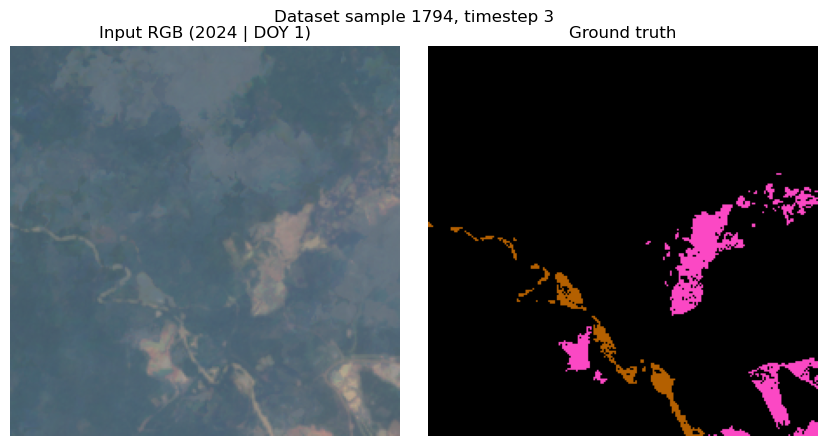

In [10]:
visualize_single_timestep_sample(val_dataset)


## UNet segmentation model

This is a pure CNN encoder-decoder with skip connections. It receives one
normalized Sentinel-style image frame shaped `(B, C, H, W)` and produces a
full-resolution multiclass segmentation map shaped `(B, NUM_CLASSES, H, W)`.


In [11]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.0):
        super().__init__()
        layers = [
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        ]
        if dropout > 0:
            layers.append(nn.Dropout2d(dropout))
        self.block = nn.Sequential(*layers)

    def forward(self, image):
        return self.block(image)


class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.0):
        super().__init__()
        self.block = nn.Sequential(
            nn.MaxPool2d(2),
            ConvBlock(in_channels, out_channels, dropout=dropout),
        )

    def forward(self, image):
        return self.block(image)


class UpBlock(nn.Module):
    def __init__(
        self,
        in_channels,
        skip_channels,
        out_channels,
        bilinear=True,
        dropout=0.0,
    ):
        super().__init__()
        if bilinear:
            self.up = nn.Upsample(
                scale_factor=2,
                mode="bilinear",
                align_corners=False,
            )
            conv_in_channels = in_channels + skip_channels
        else:
            self.up = nn.ConvTranspose2d(
                in_channels,
                out_channels,
                kernel_size=2,
                stride=2,
            )
            conv_in_channels = out_channels + skip_channels

        self.conv = ConvBlock(
            conv_in_channels, out_channels, dropout=dropout
        )

    def forward(self, image, skip):
        image = self.up(image)
        diff_y = skip.size(2) - image.size(2)
        diff_x = skip.size(3) - image.size(3)
        image = F.pad(
            image,
            [
                diff_x // 2,
                diff_x - diff_x // 2,
                diff_y // 2,
                diff_y - diff_y // 2,
            ],
        )
        image = torch.cat([skip, image], dim=1)
        return self.conv(image)


class UNetSegmentation(nn.Module):
    def __init__(
        self,
        in_channels=6,
        num_classes=3,
        base_channels=64,
        bilinear=True,
        dropout=0.0,
    ):
        super().__init__()
        self.input = ConvBlock(
            in_channels, base_channels, dropout=dropout
        )
        self.down1 = DownBlock(
            base_channels, base_channels * 2, dropout=dropout
        )
        self.down2 = DownBlock(
            base_channels * 2, base_channels * 4, dropout=dropout
        )
        self.down3 = DownBlock(
            base_channels * 4, base_channels * 8, dropout=dropout
        )
        self.down4 = DownBlock(
            base_channels * 8, base_channels * 16, dropout=dropout
        )
        self.up1 = UpBlock(
            base_channels * 16,
            base_channels * 8,
            base_channels * 8,
            bilinear=bilinear,
            dropout=dropout,
        )
        self.up2 = UpBlock(
            base_channels * 8,
            base_channels * 4,
            base_channels * 4,
            bilinear=bilinear,
            dropout=dropout,
        )
        self.up3 = UpBlock(
            base_channels * 4,
            base_channels * 2,
            base_channels * 2,
            bilinear=bilinear,
            dropout=dropout,
        )
        self.up4 = UpBlock(
            base_channels * 2,
            base_channels,
            base_channels,
            bilinear=bilinear,
            dropout=dropout,
        )
        self.head = nn.Conv2d(base_channels, num_classes, kernel_size=1)

    def forward(self, image):
        x1 = self.input(image) #224x224
        x2 = self.down1(x1) #112x112
        x3 = self.down2(x2) #56x56
        x4 = self.down3(x3) #28x28
        x5 = self.down4(x4) #14x14

        output = self.up1(x5, x4)
        output = self.up2(output, x3)
        output = self.up3(output, x2)
        output = self.up4(output, x1)
        return self.head(output)


def build_unet_segmentation(
    num_classes=3,
    in_channels=6,
    base_channels=64,
    bilinear=True,
    dropout=0.0,
):
    return UNetSegmentation(
        in_channels=in_channels,
        num_classes=num_classes,
        base_channels=base_channels,
        bilinear=bilinear,
        dropout=dropout,
    )


In [12]:
model = build_unet_segmentation(
    num_classes=NUM_CLASSES,
    in_channels=IN_CHANNELS,
    base_channels=BASE_CHANNELS,
    bilinear=True,
    dropout=0.0,
).to(device)

trainable = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)
total = sum(parameter.numel() for parameter in model.parameters())
print(f"Trainable parameters: {trainable:,}")
print(f"Total parameters:     {total:,}")


Trainable parameters: 31,386,691
Total parameters:     31,386,691


In [9]:
print(torch.cuda.memory_summary())

|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      | 124584 KiB | 124584 KiB | 124584 KiB |      0 B   |
|       from large pool | 122304 KiB | 122304 KiB | 122304 KiB |      0 B   |
|       from small pool |   2280 KiB |   2280 KiB |   2280 KiB |      0 B   |
|---------------------------------------------------------------------------|
| Active memory         | 124584 KiB | 124584 KiB | 124584 KiB |      0 B   |
|       from large pool | 122304 KiB | 122304 KiB | 122304 KiB |

## Load checkpoints

This CNN notebook does not load a pretrained Prithvi encoder. If you already
have UNet weights, set `LOAD_FINETUNED_MODEL = True` in the configuration
cell and point `FINETUNED_MODEL_PATH` to that checkpoint.

The optional loader copies only tensors whose names and shapes match this
UNet. This makes it safe to point at older UNet checkpoints while you settle
on the exact architecture.


In [13]:
def read_state_dict(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location="cpu")
    if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        checkpoint = checkpoint["state_dict"]
    return checkpoint


def clean_state_dict_keys(state):
    prefixes = (
        "module.",
        "model.",
        "net.",
        "unet.",
    )
    cleaned = {}
    for raw_key, value in state.items():
        key = raw_key
        changed = True
        while changed:
            changed = False
            for prefix in prefixes:
                if key.startswith(prefix):
                    key = key[len(prefix):]
                    changed = True
        cleaned[key] = value
    return cleaned


def load_model_state(model, checkpoint_path, device, strict=True):
    checkpoint_path = Path(checkpoint_path)
    state = clean_state_dict_keys(read_state_dict(checkpoint_path))
    missing, unexpected = model.load_state_dict(state, strict=strict)
    model.to(device)
    print(f"Loaded model from {checkpoint_path}")
    if not strict:
        print(
            f"Missing keys: {len(missing)}; "
            f"unexpected keys: {len(unexpected)}"
        )


def load_matching_model_state(model, checkpoint_path, device):
    checkpoint_path = Path(checkpoint_path)
    state = clean_state_dict_keys(read_state_dict(checkpoint_path))
    target = model.state_dict()
    compatible = {
        key: value
        for key, value in state.items()
        if key in target and target[key].shape == value.shape
    }

    if not compatible:
        print(f"No compatible tensors found in {checkpoint_path}")
        return

    missing, unexpected = model.load_state_dict(
        compatible, strict=False
    )
    model.to(device)
    print(
        f"Loaded {len(compatible)} compatible tensors from "
        f"{checkpoint_path}"
    )
    print(
        f"Skipped checkpoint tensors: {len(state) - len(compatible)}; "
        f"missing model keys: {len(missing)}; "
        f"unexpected keys: {len(unexpected)}"
    )


if LOAD_FINETUNED_MODEL:
    if FINETUNED_MODEL_PATH.exists():
        load_matching_model_state(
            model, FINETUNED_MODEL_PATH, device
        )
    else:
        print(
            "Fine-tuned model not found; skipping: "
            f"{FINETUNED_MODEL_PATH}"
        )


Loaded 110 compatible tensors from unet_state_dict.pt
Skipped checkpoint tensors: 0; missing model keys: 0; unexpected keys: 0


## Train and evaluate

Validation uses the selected single target/latest timestep for each sample.
The checkpoint with the lowest validation loss is saved to
`OUTPUT_MODEL_PATH`.


In [14]:
def model_logits(model, batch, device):
    return model(batch["image"].to(device))


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    pixels = 0
    samples = 0

    for batch in loader:
        masks = batch["mask"].to(device).long()
        logits = model_logits(model, batch, device)
        loss = criterion(logits, masks)

        batch_size = masks.shape[0]
        total_loss += loss.item() * batch_size
        samples += batch_size
        predictions = logits.argmax(dim=1)
        correct += (predictions == masks).sum().item()
        pixels += masks.numel()

    return {
        "loss": total_loss / max(samples, 1),
        "pixel_accuracy": correct / max(pixels, 1),
    }


def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs,
    checkpoint_path,
):
    checkpoint_path = Path(checkpoint_path)
    checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
    best_val_loss = float("inf")
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_pixel_accuracy": [],
    }

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        samples = 0

        progress = tqdm(
            train_loader,
            desc=f"Epoch {epoch}/{epochs}",
            unit="batch",
        )
        for batch in progress:
            masks = batch["mask"].to(device).long()
            optimizer.zero_grad(set_to_none=True)
            logits = model_logits(model, batch, device)
            loss = criterion(logits, masks)
            loss.backward()
            optimizer.step()

            batch_size = masks.shape[0]
            running_loss += loss.item() * batch_size
            samples += batch_size
            progress.set_postfix(
                train_loss=running_loss / samples
            )

        train_loss = running_loss / max(samples, 1)
        validation = evaluate(
            model, val_loader, criterion, device
        )
        history["train_loss"].append(train_loss)
        history["val_loss"].append(validation["loss"])
        history["val_pixel_accuracy"].append(
            validation["pixel_accuracy"]
        )

        if validation["loss"] < best_val_loss:
            best_val_loss = validation["loss"]
            torch.save(model.state_dict(), checkpoint_path)

        print(
            f"Epoch {epoch:02d}: "
            f"train_loss={train_loss:.4f}, "
            f"val_loss={validation['loss']:.4f}, "
            f"val_acc={validation['pixel_accuracy']:.2%}"
        )

    load_model_state(model, checkpoint_path, device, strict=True)
    return history


In [1]:
import torch

In [15]:
print(f"Allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
print(f"Reserved:  {torch.cuda.memory_reserved() / 1024**3:.2f} GB")

Allocated: 0.12 GB
Reserved:  0.12 GB


In [15]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(), lr=LEARNING_RATE
)

history = None
if RUN_TRAINING:
    history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=NUM_EPOCHS,
        checkpoint_path=OUTPUT_MODEL_PATH,
    )

    epochs = range(1, len(history["train_loss"]) + 1)
    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history["train_loss"], label="Train")
    plt.plot(epochs, history["val_loss"], label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Cross-entropy loss")
    plt.legend()
    plt.tight_layout()
    plt.show()


Epoch 1/50: 100%|██████████| 667/667 [16:12<00:00,  1.46s/batch, train_loss=0.0504]


Epoch 01: train_loss=0.0504, val_loss=0.0297, val_acc=99.03%


Epoch 2/50: 100%|██████████| 667/667 [15:44<00:00,  1.42s/batch, train_loss=0.0482]


Epoch 02: train_loss=0.0482, val_loss=0.0283, val_acc=99.07%


Epoch 3/50: 100%|██████████| 667/667 [15:45<00:00,  1.42s/batch, train_loss=0.0471]


...

Epoch 05: train_loss=0.0458, val_loss=0.0270, val_acc=99.09%


Epoch 6/50: 100%|██████████| 667/667 [15:49<00:00,  1.42s/batch, train_loss=0.0448]


Epoch 06: train_loss=0.0448, val_loss=0.0284, val_acc=99.08%


Epoch 7/50:  76%|███████▌  | 507/667 [11:55<03:45,  1.41s/batch, train_loss=0.0439]


KeyboardInterrupt: 

## Visualize input, ground truth, and prediction

The final view displays the selected target/latest RGB input alongside its
ground truth and model output.


In [28]:
#Save the final model state dict
torch.save(model.state_dict(), OUTPUT_MODEL_PATH)

In [23]:
@torch.no_grad()
def visualize_prediction(
    model,
    dataset,
    device,
    index=None,
    show=True,
):
    if index is None:
        index = random.randrange(len(dataset))

    sample = dataset[index]
    batch = {
        "image": sample["image"].unsqueeze(0),
        "mask": sample["mask"].unsqueeze(0),
    }

    model.eval()
    logits = model_logits(model, batch, device)
    prediction = logits.argmax(dim=1)[0].cpu().numpy()
    ground_truth = batch["mask"][0].cpu().numpy()

    coords = sample["temporal_coords"].cpu().numpy()
    target_timestep = int(sample["target_timestep"].item())
    target_year = int(coords[0]) if np.any(coords) else 0
    target_day = int(coords[1]) if np.any(coords) else 0
    # The U-Net receives only the last valid (target) frame. Return and
    # display that exact model input rather than the full time series.
    input_frames = [
        {
            "timestep": target_timestep,
            "year": target_year,
            "day": target_day,
            "rgb": single_rgb(sample["image"], dataset),
        }
    ]

    result = {
        "index": int(index),
        "target_year": target_year,
        "target_timestep": target_timestep,
        "inputs": input_frames,
        "ground_truth": ground_truth.astype(np.uint8),
        "prediction": prediction.astype(np.uint8),
    }

    if show:
        columns = len(input_frames) + 2
        figure, axes = plt.subplots(
            1,
            columns,
            figsize=(3.2 * columns, 4.5),
            squeeze=False,
        )
        axes = axes[0]

        for axis, frame in zip(axes[:-2], input_frames):
            axis.imshow(frame["rgb"])
            title = (
                f"Target RGB ({frame['year']} | DOY {frame['day']})"
                "\nmodel input"
            )
            axis.set_title(title)

        axes[-2].imshow(mask_to_rgb(ground_truth))
        axes[-2].set_title("Ground truth")
        axes[-1].imshow(mask_to_rgb(prediction))
        axes[-1].set_title("Prediction")

        for axis in axes:
            axis.axis("off")
        figure.suptitle(f"Validation sample {index}")
        plt.tight_layout()
        plt.show()

    return result


In [24]:
from PIL import Image


def _rgb_float_to_uint8(rgb):
    rgb = np.asarray(rgb, dtype=np.float32)
    return (np.clip(rgb, 0.0, 1.0) * 255).round().astype(np.uint8)


def _save_uint8_png(array, path):
    Image.fromarray(np.asarray(array, dtype=np.uint8)).save(path)


def save_prediction_sample(result, output_root=Path("predictions_unet")):
    sample_dir = Path(output_root) / (
        f"{result['index']}_{result['target_year']}"
    )
    inputs_dir = sample_dir / "inputs"
    mask_dir = sample_dir / "mask"
    inputs_dir.mkdir(parents=True, exist_ok=True)
    mask_dir.mkdir(parents=True, exist_ok=True)

    saved_inputs = []
    used_names = set()
    for frame in result["inputs"]:
        name = f"{frame['year']}.png"
        if name in used_names:
            name = (
                f"{frame['year']}_doy{frame['day']}"
                f"_t{frame['timestep']}.png"
            )
        used_names.add(name)

        path = inputs_dir / name
        _save_uint8_png(_rgb_float_to_uint8(frame["rgb"]), path)
        saved_inputs.append(path)

    target_year = result["target_year"]
    gt_path = mask_dir / f"{target_year}_gt.png"
    pred_path = mask_dir / f"{target_year}_pred.png"
    _save_uint8_png(result["ground_truth"], gt_path)
    _save_uint8_png(result["prediction"], pred_path)

    saved = {
        "sample_dir": sample_dir,
        "inputs": saved_inputs,
        "ground_truth": gt_path,
        "prediction": pred_path,
    }
    print(f"Saved prediction sample to {sample_dir}")
    return saved


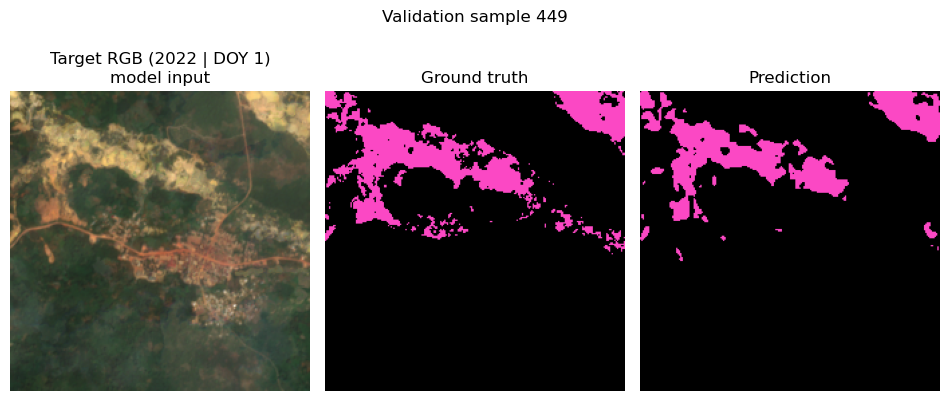

In [33]:
SAMPLE_INDEX = 449  # Set to an integer, for example 1022, to revisit a sample.

prediction_sample = visualize_prediction(
    model,
    val_dataset,
    device=device,
    index=SAMPLE_INDEX,
)


In [28]:
saved_prediction_sample = save_prediction_sample(prediction_sample)
saved_prediction_sample


Saved prediction sample to predictions_unet\2161_2019


{'sample_dir': WindowsPath('predictions_unet/2161_2019'),
 'inputs': [WindowsPath('predictions_unet/2161_2019/inputs/2019.png')],
 'ground_truth': WindowsPath('predictions_unet/2161_2019/mask/2019_gt.png'),
 'prediction': WindowsPath('predictions_unet/2161_2019/mask/2019_pred.png')}

In [29]:
REFERENCE_PREDICTIONS_ROOT = Path("predictions")
UNET_PREDICTIONS_ROOT = Path("predictions_unet")

# Read validation sample indices and target years from {sample_no}_{year}.
reference_samples = []
for sample_dir in REFERENCE_PREDICTIONS_ROOT.iterdir():
    if not sample_dir.is_dir():
        continue

    name_parts = sample_dir.name.rsplit("_", 1)
    if len(name_parts) != 2:
        continue

    sample_text, year_text = name_parts
    if sample_text.isdigit() and year_text.isdigit():
        reference_samples.append((int(sample_text), int(year_text)))

reference_samples.sort(key=lambda item: item[0])
if not reference_samples:
    raise RuntimeError(
        f"No {{sample_no}}_{{year}} folders found in "
        f"{REFERENCE_PREDICTIONS_ROOT.resolve()}"
    )

saved_unet_samples = []
for sample_index, expected_year in tqdm(
    reference_samples,
    desc="Generating matching U-Net samples",
    unit="sample",
):
    if not 0 <= sample_index < len(val_dataset):
        raise IndexError(
            f"Validation index {sample_index} from "
            f"{sample_index}_{expected_year} is out of range."
        )

    result = visualize_prediction(
        model,
        val_dataset,
        device=device,
        index=sample_index,
        show=False,
    )

    if result["target_year"] != expected_year:
        raise ValueError(
            f"Year mismatch for sample {sample_index}: folder says "
            f"{expected_year}, but the dataset target is "
            f"{result['target_year']}."
        )

    saved_unet_samples.append(
        save_prediction_sample(
            result,
            output_root=UNET_PREDICTIONS_ROOT,
        )
    )

print(
    f"Generated {len(saved_unet_samples)} matching U-Net samples in "
    f"{UNET_PREDICTIONS_ROOT.resolve()}"
)
saved_unet_samples


Generating matching U-Net samples:  23%|██▎       | 3/13 [00:00<00:00, 10.10sample/s]

Saved prediction sample to predictions_unet\47_2024
Saved prediction sample to predictions_unet\192_2024
Saved prediction sample to predictions_unet\283_2024
Saved prediction sample to predictions_unet\449_2022


Generating matching U-Net samples:  62%|██████▏   | 8/13 [00:00<00:00, 16.12sample/s]

Saved prediction sample to predictions_unet\566_2024
Saved prediction sample to predictions_unet\571_2024
Saved prediction sample to predictions_unet\700_2021
Saved prediction sample to predictions_unet\1288_2024
Saved prediction sample to predictions_unet\1849_2019


Generating matching U-Net samples: 100%|██████████| 13/13 [00:00<00:00, 15.35sample/s]

Saved prediction sample to predictions_unet\1894_2024
Saved prediction sample to predictions_unet\2161_2019
Saved prediction sample to predictions_unet\2390_2021
Saved prediction sample to predictions_unet\2494_2022
Generated 13 matching U-Net samples in C:\Users\emmanuelasare\Documents\Python\ml-env\Prithvi-EO-Segmentation\predictions_unet


[{'sample_dir': WindowsPath('predictions_unet/47_2024'),
  'inputs': [WindowsPath('predictions_unet/47_2024/inputs/2024.png')],
  'ground_truth': WindowsPath('predictions_unet/47_2024/mask/2024_gt.png'),
  'prediction': WindowsPath('predictions_unet/47_2024/mask/2024_pred.png')},
 {'sample_dir': WindowsPath('predictions_unet/192_2024'),
  'inputs': [WindowsPath('predictions_unet/192_2024/inputs/2024.png')],
  'ground_truth': WindowsPath('predictions_unet/192_2024/mask/2024_gt.png'),
  'prediction': WindowsPath('predictions_unet/192_2024/mask/2024_pred.png')},
 {'sample_dir': WindowsPath('predictions_unet/283_2024'),
  'inputs': [WindowsPath('predictions_unet/283_2024/inputs/2024.png')],
  'ground_truth': WindowsPath('predictions_unet/283_2024/mask/2024_gt.png'),
  'prediction': WindowsPath('predictions_unet/283_2024/mask/2024_pred.png')},
 {'sample_dir': WindowsPath('predictions_unet/449_2022'),
  'inputs': [WindowsPath('predictions_unet/449_2022/inputs/2022.png')],
  'ground_truth': W